**Task 1: Import all the required libraries.**

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print(tf.__version__)

2.19.0


**Task 2: Successfully load dataset.**

Task 2.1: Use Keras API to load dataset.

In [2]:
from keras.datasets import fashion_mnist
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Task 2.2: Class Names

In [3]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

**Task 3: Explore Dataset**

Task 3.1: Check shape, size, resize etc

In [4]:
print(X_train_full.shape)
print(y_train_full.shape)

print(X_test.shape)
print(y_test.shape)

X_train_full.dtype
y_train_full.dtype

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


dtype('uint8')

Task 3.2: Preprocess Data

<function matplotlib.pyplot.show(close=None, block=None)>

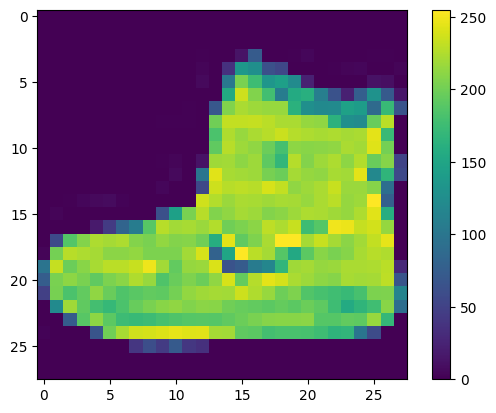

In [5]:
plt.figure()
plt.imshow(X_train_full[0])
plt.colorbar()
plt.grid(False)
plt.show

Task 3.2: Preprocess Data

In [6]:
X_valid, X_train = X_train_full[:5000] / 255.0, X_train_full[5000:] / 255.0
Y_valid, Y_train = y_train_full[:5000], y_train_full[5000: ]
X_test = X_test / 255.0

Task 3.3: Display first 25 images and its name from training set

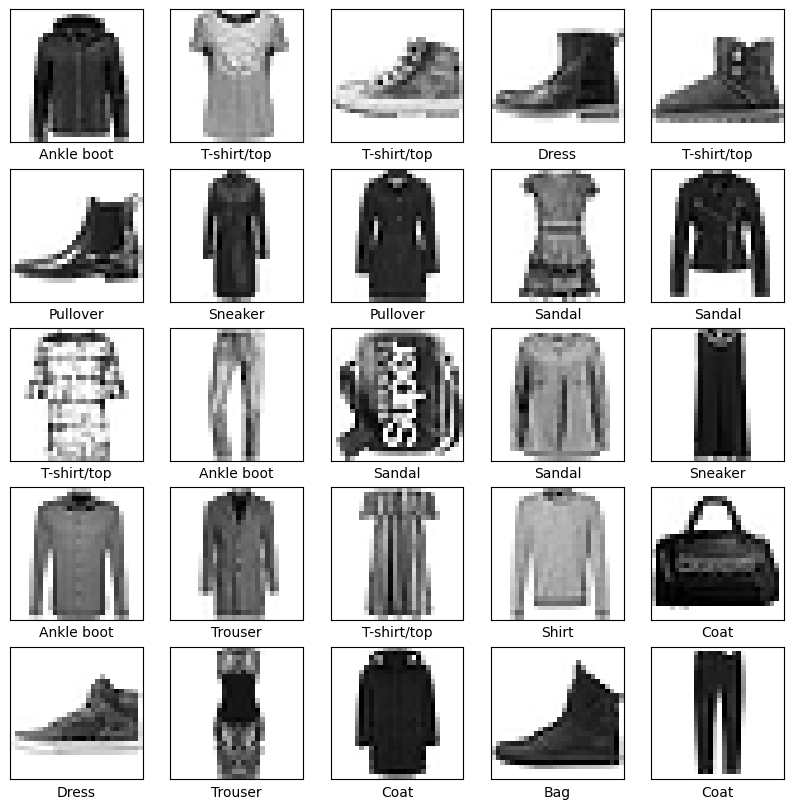

In [7]:
plt.figure(figsize=(10,10))
for i in range(25):
   plt.subplot(5,5,i+1)
   plt.xticks([])
   plt.yticks([])
   plt.grid(False)
   plt.imshow(X_train[i], cmap=plt.cm.binary)
   plt.xlabel(class_names[y_train_full[i]])
plt.show()

**Task 4: Build a neural network**

Task 4.1: Use Keras sequential API to build your model (MLP with 2 hidden layers)

In [8]:
from tensorflow import keras
from tensorflow.keras import layers

In [9]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=[28, 28]))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(300, activation="relu"))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(100, activation="relu"))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dense(10, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Task 4.2: create our sequential model

In [10]:
model = keras.Sequential([
   layers.Flatten(input_shape=(28,28)),
   layers.BatchNormalization(),
   layers.Dense(128, activation='relu'),
   layers.BatchNormalization(),
   layers.Dense(64, activation='relu'),
   layers.BatchNormalization(),
   layers.Dense(10, activation='softmax')
])

Task 4.3: Model Summary

In [11]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 784)            │         3,136 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,290 (442.54 KB)

 Trainable params: 111,338 (434.91 KB)

 Non-trainable params: 1,952 (7.62 KB)

**l1 and l2 Regularization**

In [12]:
layer = layers.Dense(100, activation="elu", kernel_initializer="he_normal", kernel_regularizer=tf.keras.regularizers.l2(0.01))

In [13]:
from functools import partial

RegularizedDense = partial(layers.Dense, activation="elu", kernel_initializer="he_normal", kernel_regularizer=tf.keras.regularizers.l2(0.01))

model = tf.keras.models.Sequential([ tf.keras.layers.Flatten(input_shape=[28, 28]),
RegularizedDense(300),
RegularizedDense(100),
RegularizedDense(10, activation="softmax",
kernel_initializer="glorot_uniform") ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

**Regularization Dropout**

In [15]:
model = tf.keras.models.Sequential([ tf.keras.layers.Flatten(input_shape=[28, 28]),
                                    layers.Dropout(rate=0.2),
                                    layers.Dense(300, activation='elu', kernel_initializer="he_normal"),
                                    layers.Dropout(rate=0.2),
                                    layers.Dense(100, activation='elu', kernel_initializer="he_normal"),
                                    layers.Dropout(rate=0.2),
                                    layers.Dense(10, activation='softmax')])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

**Task 5: Compile and train the model**

Task 5.1: Tweak learned parameters

In [25]:
# model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
#              loss='sparse_categorical_crossentropy',
#              metrics=['accuracy'])

model.compile(optimizer="sgd",
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

Task 5.2: Train the model with epochs = 50

In [ ]:
history = model.fit(X_train, Y_train, epochs = 30, validation_data = (X_valid, Y_valid), batch_size=1)

Epoch 1/30
55000/55000 ━━━━━━━━━━━━━━━━━━━━ 226s 4ms/step - accuracy: 0.8383 - loss: 0.6684 - val_accuracy: 0.8750 - val_loss: 0.5463
Epoch 2/30
55000/55000 ━━━━━━━━━━━━━━━━━━━━ 226s 4ms/step - accuracy: 0.8295 - loss: 0.6402 - val_accuracy: 0.8328 - val_loss: 0.5426
Epoch 3/30
55000/55000 ━━━━━━━━━━━━━━━━━━━━ 207s 4ms/step - accuracy: 0.8335 - loss: 0.5983 - val_accuracy: 0.8600 - val_loss: 0.5494
Epoch 4/30
55000/55000 ━━━━━━━━━━━━━━━━━━━━ 235s 4ms/step - accuracy: 0.8332 - loss: 0.6049 - val_accuracy: 0.8422 - val_loss: 0.6096
Epoch 5/30
55000/55000 ━━━━━━━━━━━━━━━━━━━━ 255s 5ms/step - accuracy: 0.8340 - loss: 0.5886 - val_accuracy: 0.8516 - val_loss: 0.5658
Epoch 6/30
35689/55000 ━━━━━━━━━━━━━━━━━━━━ 1:11 4ms/step - accuracy: 0.8339 - loss: 0.6090

**Task 6: Plot learning curve:**

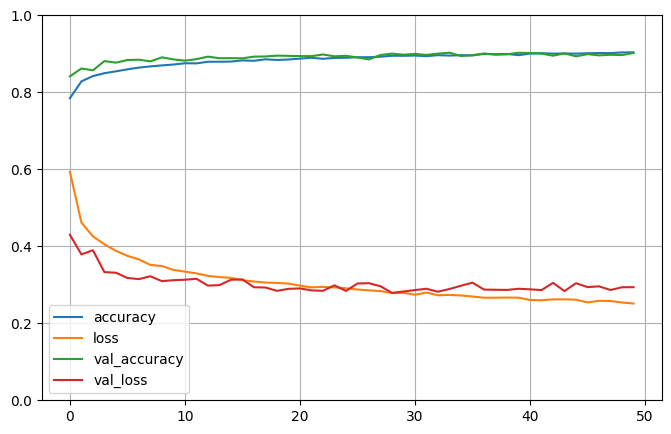

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

pd.DataFrame(history.history).plot(figsize = (8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

**Task 7: Evaluate the test accuracy:**

In [20]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print('\n Test Accuracy: ', test_acc)
print('\n Test Loss: ', test_loss)

313/313 - 3s - 10ms/step - accuracy: 0.8941 - loss: 0.3185

 Test Accuracy:  0.89410001039505

 Test Loss:  0.318522572517395


**Task 8: Make prediction on the test dataset.**

Task 8.1:

In [21]:
probability_model = tf.keras.Sequential([model, tf.keras.layers.Softmax()])
predictions = probability_model.predict(X_test)
predictions[0]

print(class_names[np.argmax(predictions[0])])
np.argmax(predictions[0])


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Ankle boot


np.int64(9)

Task 8.2: Examine with test label (y_test)

In [22]:
y_test[0]

np.uint8(9)